# TEST OUT COMPONENTS

This file is my sandbox to test different components before putting things together to see how the outputs look, if things work correctly etc.

In [1]:
import matplotlib.pyplot as plt
from kitty import depth_read, listPicsWith, togglePath, MatchDepthToCar, KITTY_PATH, CAR_YOLO_CLASSES, KITTY_CONF
from ultralytics import YOLO
from PIL import Image
import numpy as np
import cv2

In [2]:
ds_path = "../datasets/depth_selection/val_selection_cropped/image/"
search_for = ["car"]

#listPicsWith(ds_path, search_for, True)

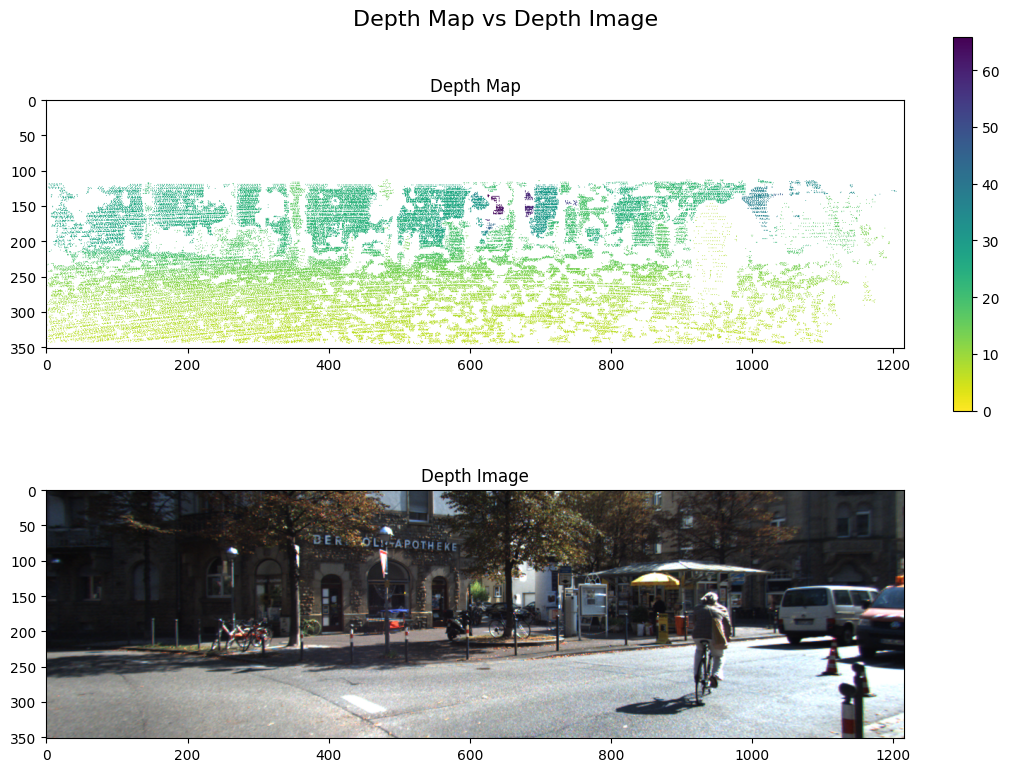

In [3]:
depth_map = "../datasets/depth_selection/val_selection_cropped/groundtruth_depth/2011_09_26_drive_0005_sync_groundtruth_depth_0000000071_image_03.png"
depth_map_img = togglePath(depth_map)

depth_img = np.array(Image.open(depth_map_img), dtype=int)

depth_np = depth_read(depth_map)

cmap = plt.cm.viridis_r.copy()
cmap.set_under('white')   # values below vmin
cmap.set_over('white') 

fig, ax = plt.subplots(2, 1, figsize=(10, 8), constrained_layout=True)

# First image
im = ax[0].imshow(depth_np, cmap=cmap, vmin=0)
fig.colorbar(im, ax=ax[0])
ax[0].set_title("Depth Map")
ax[0].set_anchor('C')   # center image

# Second image
ax[1].imshow(depth_img)
ax[1].set_title("Depth Image")
ax[1].set_anchor('C')   # center image

plt.suptitle("Depth Map vs Depth Image", fontsize=16)
plt.show()

## Extracting true depth from an image

1. Find all images with cars in them with over 50% certainty
2. Use YOLO to find bounding boxes for each image
3. For each image:
    1. crop the depth image to the car bounding box
    2. convert depth using devkit function to m from image
    4. drop the invalid points (where depth is -1)
    3. compute exact value either as average or RANSACK fitted value in the middle of the image

Both avergaes and ransac predictions in the middle are stored in a numpy array for further visualizations

In [4]:
images_with_cars = listPicsWith(KITTY_PATH, CAR_YOLO_CLASSES, KITTY_CONF, True)

1000
2011_09_26_drive_0002_sync_image_0000000005_image_02.png
../datasets/depth_selection/val_selection_cropped/image/2011_09_26_drive_0002_sync_image_0000000005_image_02.png

0: 192x640 (no detections), 22.6ms
1: 192x640 (no detections), 22.6ms
2: 192x640 (no detections), 22.6ms
3: 192x640 (no detections), 22.6ms
4: 192x640 (no detections), 22.6ms
5: 192x640 (no detections), 22.6ms
6: 192x640 (no detections), 22.6ms
7: 192x640 (no detections), 22.6ms
8: 192x640 (no detections), 22.6ms
9: 192x640 (no detections), 22.6ms
10: 192x640 (no detections), 22.6ms
11: 192x640 (no detections), 22.6ms
12: 192x640 (no detections), 22.6ms
13: 192x640 (no detections), 22.6ms
14: 192x640 (no detections), 22.6ms
15: 192x640 (no detections), 22.6ms
16: 192x640 (no detections), 22.6ms
17: 192x640 (no detections), 22.6ms
18: 192x640 (no detections), 22.6ms
19: 192x640 (no detections), 22.6ms
20: 192x640 (no detections), 22.6ms
21: 192x640 1 car, 22.6ms
22: 192x640 1 car, 22.6ms
23: 192x640 1 car, 22.6ms


In [5]:
model = YOLO("../build/yolo26n.pt")

results = model.predict(images_with_cars, conf=KITTY_CONF, classes=CAR_YOLO_CLASSES)

ransac_preds_combined = np.array([])
avgs_combined = np.array([])
for i, image_path in enumerate(images_with_cars):
    print(f"Progress: {i/len(images_with_cars)*100:.2f}%")
    result = results[i]
    img = cv2.imread(image_path)
    ransac_preds, avgs = MatchDepthToCar(image_path, result)

    ransac_preds_combined = np.append(ransac_preds_combined, ransac_preds)
    avgs_combined = np.append(avgs_combined, avgs)


#WE NOW HOW THE TOTAL RESULTS FOR THE IMAGES
print(f"Ransac shape {ransac_preds_combined.shape} and avgs shape {avgs_combined.shape} values are ransac: {ransac_preds_combined[:10]}")


0: 192x640 1 car, 24.4ms
1: 192x640 1 car, 24.4ms
2: 192x640 1 car, 24.4ms
3: 192x640 1 car, 24.4ms
4: 192x640 1 car, 24.4ms
5: 192x640 1 car, 24.4ms
6: 192x640 1 car, 24.4ms
7: 192x640 1 car, 24.4ms
8: 192x640 1 car, 24.4ms
9: 192x640 1 car, 24.4ms
10: 192x640 2 cars, 24.4ms
11: 192x640 1 car, 24.4ms
12: 192x640 1 car, 24.4ms
13: 192x640 2 cars, 24.4ms
14: 192x640 2 cars, 24.4ms
15: 192x640 2 cars, 24.4ms
16: 192x640 1 car, 24.4ms
17: 192x640 2 cars, 24.4ms
18: 192x640 1 car, 24.4ms
19: 192x640 1 car, 24.4ms
20: 192x640 1 car, 24.4ms
21: 192x640 2 cars, 24.4ms
22: 192x640 1 car, 24.4ms
23: 192x640 1 car, 24.4ms
24: 192x640 1 car, 24.4ms
25: 192x640 2 cars, 24.4ms
26: 192x640 1 car, 24.4ms
27: 192x640 1 car, 24.4ms
28: 192x640 2 cars, 24.4ms
29: 192x640 2 cars, 24.4ms
30: 192x640 3 cars, 24.4ms
31: 192x640 4 cars, 24.4ms
32: 192x640 3 cars, 24.4ms
33: 192x640 4 cars, 24.4ms
34: 192x640 3 cars, 24.4ms
35: 192x640 5 cars, 24.4ms
36: 192x640 4 cars, 24.4ms
37: 192x640 5 cars, 24.4ms
38: 

/home/tim/sidehustle/thesis/.venv/lib64/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tim/sidehustle/thesis/.venv/lib64/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Managed to avoid the error?
Progress: 23.32%
Progress: 23.45%
Progress: 23.58%
Progress: 23.70%
Progress: 23.83%
Progress: 23.96%
Progress: 24.09%
Progress: 24.22%
Progress: 24.35%


/home/tim/sidehustle/thesis/.venv/lib64/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tim/sidehustle/thesis/.venv/lib64/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Managed to avoid the error?
Progress: 24.48%
Progress: 24.61%
Progress: 24.74%
Progress: 24.87%
Progress: 25.00%
Progress: 25.13%
Progress: 25.26%
Progress: 25.39%
Progress: 25.52%
Progress: 25.65%
Progress: 25.78%
Progress: 25.91%
Progress: 26.04%
Progress: 26.17%
Progress: 26.30%
Progress: 26.42%
Progress: 26.55%
Progress: 26.68%
Progress: 26.81%
Progress: 26.94%
Progress: 27.07%
Progress: 27.20%
Progress: 27.33%
Progress: 27.46%
Progress: 27.59%
Progress: 27.72%
Progress: 27.85%
Progress: 27.98%
Progress: 28.11%
Progress: 28.24%
Progress: 28.37%
Progress: 28.50%
Progress: 28.63%
Progress: 28.76%
Progress: 28.89%
Progress: 29.02%
Progress: 29.15%
Progress: 29.27%
Progress: 29.40%
Progress: 29.53%
Progress: 29.66%
Progress: 29.79%
Progress: 29.92%
Progress: 30.05%
Progress: 30.18%
Progress: 30.31%
Progress: 30.44%
Progress: 30.57%
Progress: 30.70%
Progress: 30.83%
Progress: 30.96%
Progress: 31.09%
Progress: 31.22%
Progress: 31.35%
Progress: 31.48%
Progress: 31.61%
Progress: 31.74%
Pro

/home/tim/sidehustle/thesis/.venv/lib64/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tim/sidehustle/thesis/.venv/lib64/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Progress: 34.59%
Progress: 34.72%
Progress: 34.84%
Progress: 34.97%
Progress: 35.10%
Progress: 35.23%
Progress: 35.36%
Progress: 35.49%
Progress: 35.62%
Progress: 35.75%
Progress: 35.88%
Progress: 36.01%
Progress: 36.14%
Progress: 36.27%
Progress: 36.40%
Progress: 36.53%
Progress: 36.66%
Progress: 36.79%
Progress: 36.92%
Progress: 37.05%
Progress: 37.18%
Progress: 37.31%
Progress: 37.44%
Progress: 37.56%
Progress: 37.69%
Progress: 37.82%
Progress: 37.95%
Progress: 38.08%
Progress: 38.21%
Progress: 38.34%
Progress: 38.47%
Progress: 38.60%
Progress: 38.73%
Progress: 38.86%
Progress: 38.99%
Progress: 39.12%
Progress: 39.25%
Progress: 39.38%
Progress: 39.51%
Progress: 39.64%
Progress: 39.77%
Progress: 39.90%
Progress: 40.03%
Progress: 40.16%
Progress: 40.28%
Progress: 40.41%
Progress: 40.54%
Progress: 40.67%
Progress: 40.80%
Progress: 40.93%
Progress: 41.06%
Progress: 41.19%
Progress: 41.32%
Progress: 41.45%
Progress: 41.58%
Progress: 41.71%
Progress: 41.84%
Progress: 41.97%
Progress: 42.1

/home/tim/sidehustle/thesis/.venv/lib64/python3.12/site-packages/numpy/_core/fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/tim/sidehustle/thesis/.venv/lib64/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Progress: 43.52%
Progress: 43.65%
Progress: 43.78%
Progress: 43.91%
Progress: 44.04%
Progress: 44.17%
Progress: 44.30%
Progress: 44.43%
Progress: 44.56%
Progress: 44.69%
Progress: 44.82%
Progress: 44.95%
Progress: 45.08%
Progress: 45.21%
Progress: 45.34%
Progress: 45.47%
Progress: 45.60%
Progress: 45.73%
Progress: 45.85%
Progress: 45.98%
Progress: 46.11%
Progress: 46.24%
Progress: 46.37%
Progress: 46.50%
Progress: 46.63%
Progress: 46.76%
Progress: 46.89%
Progress: 47.02%
Progress: 47.15%
Progress: 47.28%
Progress: 47.41%
Progress: 47.54%
Progress: 47.67%
Progress: 47.80%
Progress: 47.93%
Progress: 48.06%
Progress: 48.19%
Progress: 48.32%
Progress: 48.45%
Progress: 48.58%
Progress: 48.70%
Progress: 48.83%
Progress: 48.96%
Progress: 49.09%
Progress: 49.22%
Progress: 49.35%
Progress: 49.48%
Progress: 49.61%
Progress: 49.74%
Progress: 49.87%
Progress: 50.00%
Progress: 50.13%
Progress: 50.26%
Progress: 50.39%
Progress: 50.52%
Progress: 50.65%
Progress: 50.78%
Progress: 50.91%
Progress: 51.0

In [6]:
ratios_combined = (ransac_preds_combined-avgs_combined)/avgs_combined *100
ratios_combined_inv = (avgs_combined-ransac_preds_combined)/ransac_preds_combined *100

# Plotting results

After getting ransac values of the middle of the image I want to visualize the results.

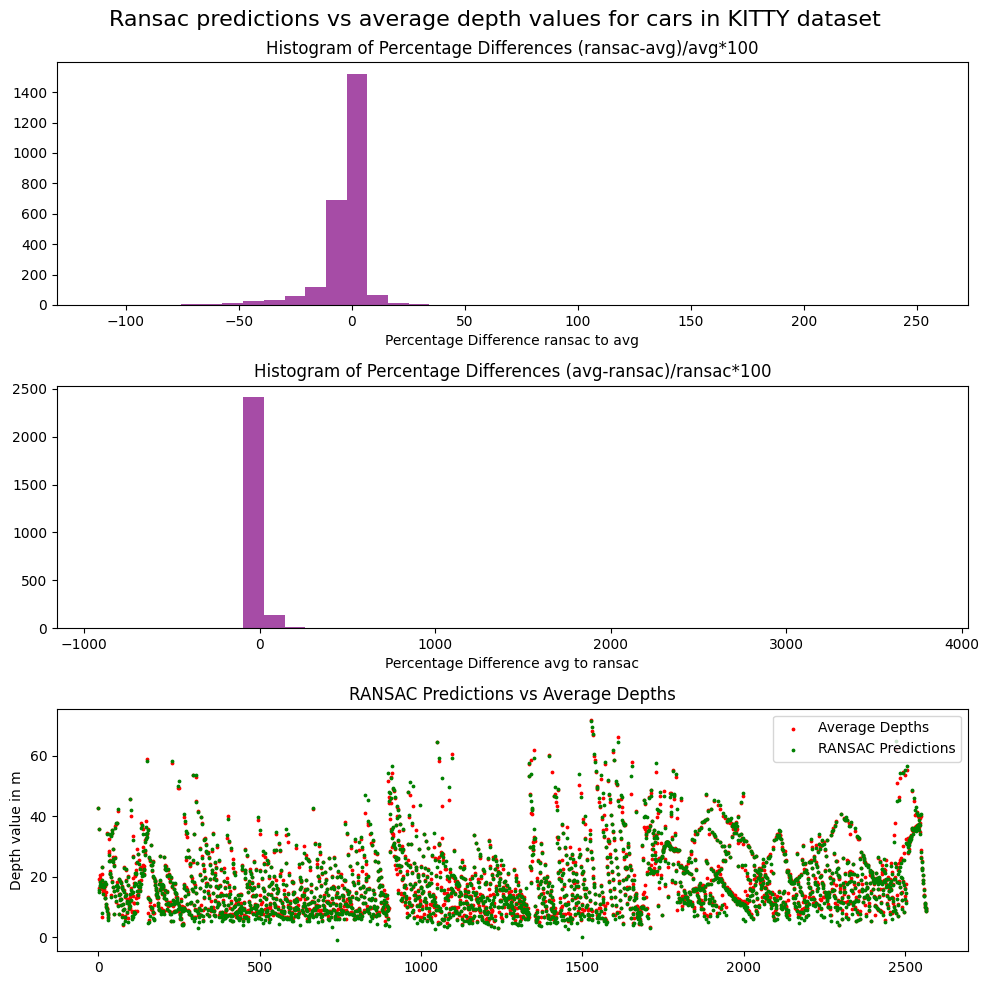

In [13]:
fig, ax = plt.subplots(nrows=3, ncols=1,figsize=(10, 10))

axes = ax.flatten()

axes[0].hist(ratios_combined, bins=40, color='purple', alpha=0.7)
axes[0].set_title('Histogram of Percentage Differences (ransac-avg)/avg*100')
axes[0].set_xlabel('Percentage Difference ransac to avg')

axes[1].hist(ratios_combined_inv, bins=40, color='purple', alpha=0.7)
axes[1].set_title('Histogram of Percentage Differences (avg-ransac)/ransac*100')
axes[1].set_xlabel('Percentage Difference avg to ransac')

indicies = np.arange(len(ratios_combined))
axes[2].scatter(indicies, avgs_combined, color='red', label='Average Depths', s=3)
axes[2].scatter(indicies, ransac_preds_combined, color='green', label='RANSAC Predictions',s=3)
axes[2].set_title('RANSAC Predictions vs Average Depths')
axes[2].set_ylabel("Depth value in m")

plt.suptitle("Ransac predictions vs average depth values for cars in KITTY dataset", fontsize=16)
plt.tight_layout()
plt.legend()
plt.show()